# Rep 2. Checkpoint 2. Movimiento Browniano Estándar

### Instrucciones generales

El objetivo de la actividad es construir desde cero una simulación de movimiento browniano y analizar cómo cambia su distribución final cuando se modifica el horizonte temporal.

No se proporciona código base. Cada estudiante debe implementar la simulación utilizando Python.

Se permite utilizar únicamente las librerías:

* numpy
* matplotlib

 

### Parte 1 — Simulación del proceso

1. Simular trayectorias de movimiento browniano estándar.

2. Utilizar al menos 5,000 simulaciones independientes.

3. Trabajar con los siguientes horizontes temporales:

   * T = 0.25
   * T = 0.5
   * T = 1
   * T = 2

4. Para cada horizonte temporal:

   * Discretizar el intervalo usando 252 pasos.
   * Generar incrementos normales con media cero.
   * Asegurar que la varianza escale correctamente con el tamaño del paso.
   * Calcular el valor final del proceso en el tiempo T.

El resultado debe ser un conjunto de valores finales para cada horizonte.

 

### Parte 2 — Visualización

Construir una gráfica que muestre, en una misma figura:

* La distribución final del proceso para cada horizonte temporal.
* Utilizar histogramas superpuestos.
* Incluir leyenda y títulos adecuados.

La visualización debe permitir comparar claramente la dispersión de cada caso.

 

### Parte 3 — Análisis cuantitativo

Para cada horizonte temporal calcular:

* Media empírica
* Varianza empírica
* Desviación estándar empírica

Presentar los resultados en una tabla.

### Parte 4 — Preguntas de análisis

Responder de forma breve y precisa, usando Markdown en el notebook:

1. ¿Cómo cambia la dispersión de la distribución al aumentar el horizonte temporal?
2. ¿La media del proceso depende del tiempo?
3. ¿Qué relación observas entre la varianza y el tiempo?
4. Si el horizonte temporal se cuadruplica, ¿qué ocurre aproximadamente con la desviación estándar?
5. ¿Qué implicaciones tiene este comportamiento para el riesgo financiero a distintos horizontes?

## Parte 1 — Simulación del proceso


In [8]:
import numpy as np
import matplotlib.pyplot as plt

n_sim=50000
n_pasos=252
tiempos= [0.25, 0.5, 1, 2]

resultados = {}
for i in range(len(tiempos)):
    dt=tiempos[i]/n_pasos
    increments= np.random.normal(0, np.sqrt(dt), size=(n_sim, n_pasos))
    W = np.cumsum(increments, axis=1)
    resultados[i]=W
resultados

{0: array([[-0.02039675, -0.02564522, -0.0079002 , ...,  0.20684973,
          0.18460408,  0.20138583],
        [ 0.03400289,  0.00752885,  0.02444253, ...,  0.25713882,
          0.25369216,  0.28385687],
        [ 0.00725318, -0.00784748, -0.03335919, ..., -0.11908546,
         -0.08971661, -0.11705906],
        ...,
        [ 0.02308641,  0.01761668,  0.03712317, ..., -0.43935389,
         -0.43771773, -0.39634394],
        [ 0.05672346, -0.01027427,  0.03781501, ..., -0.21043372,
         -0.18933997, -0.22324751],
        [-0.03035228, -0.03668681, -0.01820904, ..., -0.29223893,
         -0.30618684, -0.32019513]]),
 1: array([[ 0.01180818,  0.02613175,  0.03521772, ...,  1.54351009,
          1.53681933,  1.49034784],
        [-0.06183383, -0.09719666, -0.08080362, ..., -0.84542384,
         -0.77715199, -0.75159054],
        [-0.01384397, -0.00537415,  0.00431059, ...,  0.53422727,
          0.60028962,  0.66857334],
        ...,
        [-0.03907163, -0.04721077,  0.00190332, 

## Parte 2 — Visualización


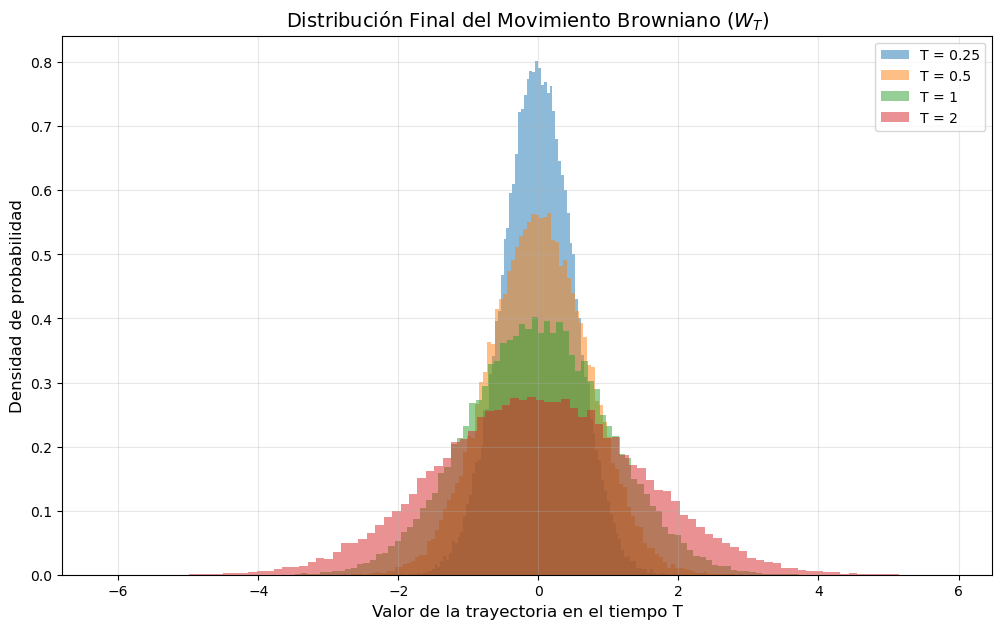

In [6]:
plt.figure(figsize=(12, 7))

for i, T in enumerate(tiempos):
    valores_finales = resultados[i][:, -1]
    
    plt.hist(valores_finales, bins=100, alpha=0.5, 
             label=f'T = {T}', density=True) # density=True ayuda a comparar formas

plt.title('Distribución Final del Movimiento Browniano ($W_T$)', fontsize=14)
plt.xlabel('Valor de la trayectoria en el tiempo T', fontsize=12)
plt.ylabel('Densidad de probabilidad', fontsize=12)
plt.legend()
plt.grid(alpha=0.3)
plt.show()


## Parte 3 — Análisis cuantitativo

In [4]:

print(f"{'Horizonte (T)':<15} | {'Media':<10} | {'Varianza':<10} | {'Desv. Est.':<10}")
print("-" * 55)

for i, T in enumerate(tiempos):
    finales = resultados[i][:, -1] # Valores en el horizonte final
    
    media_emp = np.mean(finales)
    var_emp = np.var(finales)
    std_emp = np.std(finales)
    
    print(f"{T:<15} | {media_emp:10.4f} | {var_emp:10.4f} | {std_emp:10.4f}")

Horizonte (T)   | Media      | Varianza   | Desv. Est.
-------------------------------------------------------
0.25            |    -0.0002 |     0.2536 |     0.5036
0.5             |    -0.0037 |     0.4978 |     0.7055
1               |    -0.0034 |     0.9953 |     0.9976
2               |    -0.0039 |     1.9904 |     1.4108


## Parte 4 — Preguntas de análisis
Responder de forma breve y precisa, usando Markdown en el notebook:

1. ¿Cómo cambia la dispersión de la distribución al aumentar el horizonte temporal?
- La dispersion aumenta conforme el horizonte aumenta.

2. ¿La media del proceso depende del tiempo?
- La media parece no depender del tiempo

3. ¿Qué relación observas entre la varianza y el tiempo?
- Parece crecer de manera lineal. Cuando el horizonte se duplica tambien lo hace la varianza.

4. Si el horizonte temporal se cuadruplica, ¿qué ocurre aproximadamente con la desviación estándar?
- Cuando el horizonte temporal se cuadruplica la desviacion estandar se duplica, crece como la raiz cuadrada.

5. ¿Qué implicaciones tiene este comportamiento para el riesgo financiero a distintos horizontes?
- Que el riesgo no crece de manera lineal con el tiempo, sino como una raiz cuadrada y que entre mas tiempo pase menor riesgo hay a comparacion del tiempo.
